In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import linregress

In [2]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

perf = pd.read_csv("../data/raw/07_scheme_performance.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [3]:
nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

In [4]:
nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

In [5]:
nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


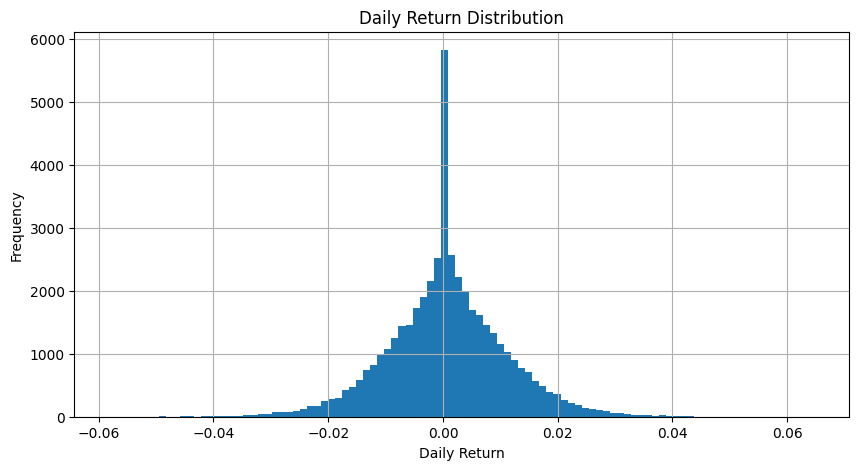

In [6]:
plt.figure(figsize=(10,5))

nav["daily_return"].dropna().hist(
    bins=100
)

plt.title("Daily Return Distribution")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.show()

In [7]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [8]:
def calculate_cagr(df, years):

    end_date = df["date"].max()

    start_date = end_date - pd.DateOffset(years=years)

    temp = df[df["date"] >= start_date]

    if len(temp) < 2:
        return np.nan

    start_nav = temp.iloc[0]["nav"]

    end_nav = temp.iloc[-1]["nav"]

    return (
        (end_nav/start_nav)
        **
        (1/years)
        -1
    ) * 100

In [9]:
cagr_results = []

for scheme in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == scheme
    ]

    cagr_results.append([
        scheme,
        calculate_cagr(temp,1),
        calculate_cagr(temp,3),
        calculate_cagr(temp,5)
    ])

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr_1yr",
        "cagr_3yr",
        "cagr_5yr"
    ]
)

In [10]:
rf = 0.065

In [11]:
sharpe_results = []

for scheme in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == scheme
    ]

    returns = temp["daily_return"].dropna()

    mean_return = returns.mean()

    std_return = returns.std()

    sharpe = (
        (mean_return - rf/252)
        /
        std_return
    ) * np.sqrt(252)

    sharpe_results.append(
        [scheme,sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

In [12]:
sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

In [13]:
sortino_results = []

In [14]:
for scheme in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == scheme
    ]

    returns = temp["daily_return"].dropna()

    downside = returns[
        returns < 0
    ]

    downside_std = downside.std()

    sortino = (
        (returns.mean()-rf/252)
        /
        downside_std
    ) * np.sqrt(252)

    sortino_results.append(
        [scheme,sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

In [15]:
benchmark["close_value"] = pd.to_numeric(
    benchmark["close_value"]
)

In [16]:
nifty100 = benchmark[
    benchmark["index_name"]=="NIFTY100"
].copy()

In [17]:
nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

In [18]:
alpha_beta_results = []

In [19]:
for scheme in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"]==scheme
    ][["date","daily_return"]]

    merged = fund.merge(
        nifty100[
            ["date","benchmark_return"]
        ],
        on="date"
    ).dropna()

    slope,intercept,r,p,se = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    beta = slope

    alpha = intercept * 252

    alpha_beta_results.append([
        scheme,
        alpha,
        beta
    ])

In [20]:
alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

In [21]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [22]:
drawdown_results = []

In [23]:
for scheme in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"]==scheme
    ].copy()

    temp["running_max"] = (
        temp["nav"].cummax()
    )

    temp["drawdown"] = (
        temp["nav"]
        /
        temp["running_max"]
        -1
    )

    max_dd = temp["drawdown"].min()

    drawdown_results.append(
        [scheme,max_dd]
    )

In [24]:
drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

In [25]:
scorecard = (
    cagr_df
    .merge(sharpe_df)
    .merge(alpha_beta_df)
    .merge(drawdown_df)
    .merge(
        fund_master[
            ["amfi_code",
             "expense_ratio_pct"]
        ]
    )
)

In [26]:
scorecard["return_rank"] = (
    scorecard["cagr_3yr"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(pct=True)
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(
        pct=True,
        ascending=False
    )
)

scorecard["dd_rank"] = (
    scorecard["max_drawdown"]
    .rank(
        pct=True,
        ascending=False
    )
)

In [27]:
scorecard["fund_score"] = (

    scorecard["return_rank"] * 30 +

    scorecard["sharpe_rank"] * 25 +

    scorecard["alpha_rank"] * 20 +

    scorecard["expense_rank"] * 15 +

    scorecard["dd_rank"] * 10

)

In [28]:
scorecard["fund_score"] = (
    scorecard["fund_score"]
    /
    scorecard["fund_score"].max()
) * 100

In [29]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [30]:
top5 = (
    scorecard
    .sort_values(
        "fund_score",
        ascending=False
    )
    .head(5)
)

In [31]:
nav["normalized_nav"] = (
    nav.groupby("amfi_code")["nav"]
    .transform(
        lambda x:
        x/x.iloc[0]*100
    )
)

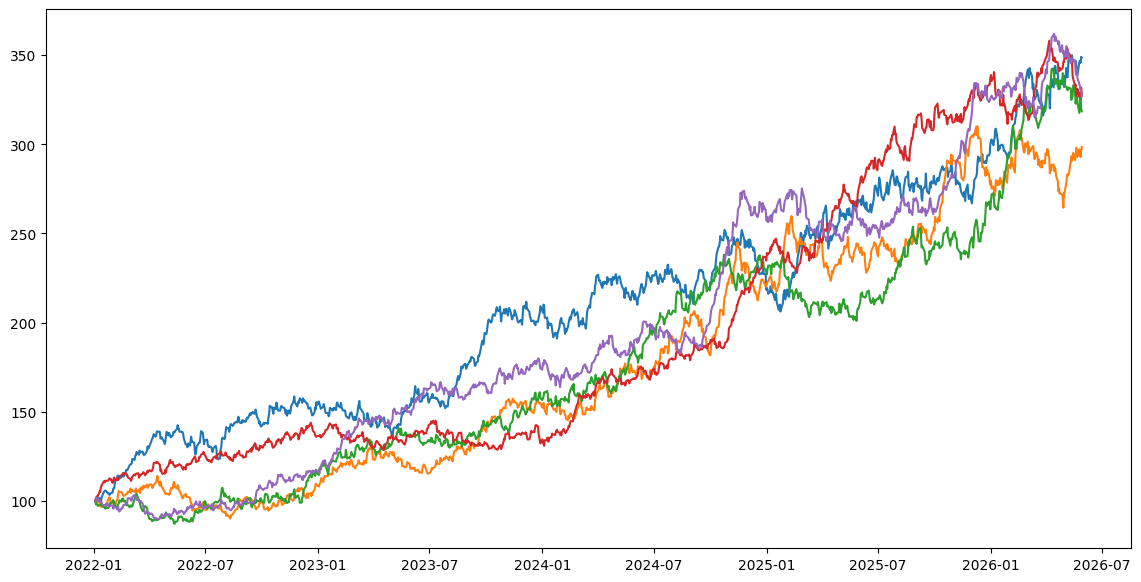

In [32]:
plt.figure(figsize=(14,7))

for scheme in top5["amfi_code"]:

    temp = nav[
        nav["amfi_code"]==scheme
    ]

    plt.plot(
        temp["date"],
        temp["normalized_nav"],
        label=str(scheme)
    )

C:\Users\varsh\AppData\Local\Temp\ipykernel_9464\506587000.py:1: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


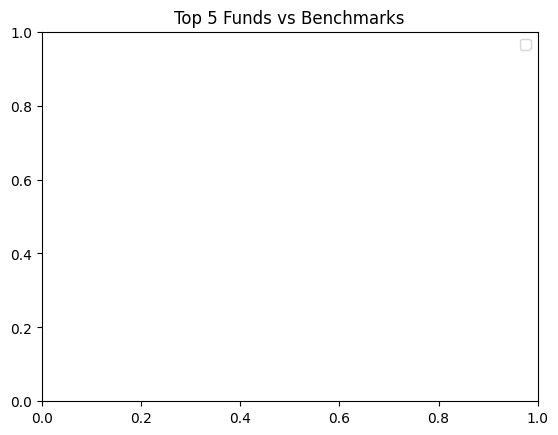

In [33]:
plt.legend()

plt.title(
    "Top 5 Funds vs Benchmarks"
)

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300
)

plt.show()

In [34]:
import pandas as pd

scorecard = pd.read_csv("../reports/fund_scorecard.csv")

print(scorecard.shape)

scorecard.head()

(40, 15)


,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score
0,100016,-2.224271,1.292649,2.316843,-0.201517,0.037476,-0.058268,-0.247344,1.55,0.150,0.150,0.050,0.2250,0.850,25.000000
1,100025,3.704969,3.916390,3.912653,-0.567095,0.042818,0.001158,-0.043083,0.56,0.175,0.050,0.075,0.9750,0.100,27.958580
2,100033,53.232396,32.442459,26.074068,1.093699,0.271954,0.005104,-0.162172,1.38,0.925,0.850,0.875,0.6000,0.500,95.266272
3,101206,47.924120,28.967695,20.442730,1.027213,0.213998,0.021086,-0.112916,1.60,0.800,0.800,0.725,0.1125,0.225,73.890533
4,101207,-23.986032,-4.152381,6.953336,0.162661,0.108971,-0.065289,-0.354469,1.53,0.050,0.325,0.350,0.3125,0.950,36.464497


In [35]:
alpha_beta = pd.read_csv("../reports/alpha_beta.csv")

print(alpha_beta.shape)

alpha_beta.head()

(40, 3)


,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [36]:
scorecard.sort_values(
    "fund_score",
    ascending=False
).head(10)

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score
25,120505,29.604659,31.777537,28.376762,1.180101,0.292636,0.000549,-0.181885,1.36,0.900,0.900,0.950,0.6500,0.625,100.000000
16,119094,22.261065,35.111802,24.445309,0.998231,0.260767,-0.066265,-0.209609,1.38,1.000,0.750,0.800,0.6000,0.700,95.562130
2,100033,53.232396,32.442459,26.074068,1.093699,0.271954,0.005104,-0.162172,1.38,0.925,0.850,0.875,0.6000,0.500,95.266272
34,148567,20.360678,34.000916,26.799277,1.448291,0.269838,0.023684,-0.112657,1.46,0.975,1.000,0.850,0.4500,0.200,94.674556
30,120843,26.657082,29.582770,26.742494,1.306744,0.273305,-0.022830,-0.129740,1.45,0.850,0.975,0.900,0.4750,0.325,92.603550
24,120504,13.064279,32.487429,20.234028,1.026524,0.211948,0.016232,-0.125883,0.80,0.950,0.775,0.700,0.7250,0.300,89.644970
21,119598,82.776059,26.669922,28.033224,0.945308,0.303370,-0.023196,-0.287060,1.43,0.725,0.675,1.000,0.5000,0.900,88.905325
39,149324,65.138719,27.000427,27.917430,0.949796,0.300579,0.011455,-0.311719,1.52,0.775,0.700,0.975,0.3625,0.925,88.683432
36,148569,39.751761,29.178902,27.629860,1.234930,0.282704,0.018134,-0.163967,1.60,0.825,0.950,0.925,0.1125,0.525,87.500000
19,119551,60.437341,30.456524,22.384873,1.208267,0.232010,-0.031751,-0.150124,1.54,0.875,0.925,0.775,0.2625,0.425,86.464497


In [37]:
alpha_beta.describe()

,amfi_code,alpha,beta
count,40.000000,40.000000,40.000000
mean,120247.000000,0.159085,-0.001958
std,14534.998667,0.087528,0.035194
min,100016.000000,0.028969,-0.066951
25%,118632.750000,0.068612,-0.023937
50%,119551.500000,0.162326,-0.000067
75%,120842.250000,0.221723,0.017026
max,149324.000000,0.303370,0.103497


In [38]:
alpha_beta.isnull().sum()

amfi_code    0
alpha        0
beta         0
dtype: int64

In [39]:
scorecard.columns

Index(['amfi_code', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr', 'sharpe_ratio',
       'alpha', 'beta', 'max_drawdown', 'expense_ratio_pct', 'return_rank',
       'sharpe_rank', 'alpha_rank', 'expense_rank', 'dd_rank', 'fund_score'],
      dtype='str')

In [40]:
scorecard["fund_score"].describe()

count     40.000000
mean      60.650888
std       23.964632
min       23.446746
25%       39.330621
50%       61.316568
75%       81.804734
max      100.000000
Name: fund_score, dtype: float64

In [43]:
print("Min Score:", scorecard["fund_score"].min())
print("Max Score:", scorecard["fund_score"].max())

Min Score: 23.44674556213018
Max Score: 100.0


In [42]:
scorecard.sort_values(
    "fund_score",
    ascending=False
).head(10)

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score
25,120505,29.604659,31.777537,28.376762,1.180101,0.292636,0.000549,-0.181885,1.36,0.900,0.900,0.950,0.6500,0.625,100.000000
16,119094,22.261065,35.111802,24.445309,0.998231,0.260767,-0.066265,-0.209609,1.38,1.000,0.750,0.800,0.6000,0.700,95.562130
2,100033,53.232396,32.442459,26.074068,1.093699,0.271954,0.005104,-0.162172,1.38,0.925,0.850,0.875,0.6000,0.500,95.266272
34,148567,20.360678,34.000916,26.799277,1.448291,0.269838,0.023684,-0.112657,1.46,0.975,1.000,0.850,0.4500,0.200,94.674556
30,120843,26.657082,29.582770,26.742494,1.306744,0.273305,-0.022830,-0.129740,1.45,0.850,0.975,0.900,0.4750,0.325,92.603550
24,120504,13.064279,32.487429,20.234028,1.026524,0.211948,0.016232,-0.125883,0.80,0.950,0.775,0.700,0.7250,0.300,89.644970
21,119598,82.776059,26.669922,28.033224,0.945308,0.303370,-0.023196,-0.287060,1.43,0.725,0.675,1.000,0.5000,0.900,88.905325
39,149324,65.138719,27.000427,27.917430,0.949796,0.300579,0.011455,-0.311719,1.52,0.775,0.700,0.975,0.3625,0.925,88.683432
36,148569,39.751761,29.178902,27.629860,1.234930,0.282704,0.018134,-0.163967,1.60,0.825,0.950,0.925,0.1125,0.525,87.500000
19,119551,60.437341,30.456524,22.384873,1.208267,0.232010,-0.031751,-0.150124,1.54,0.875,0.925,0.775,0.2625,0.425,86.464497


In [44]:
scorecard["fund_score"].describe()

count     40.000000
mean      60.650888
std       23.964632
min       23.446746
25%       39.330621
50%       61.316568
75%       81.804734
max      100.000000
Name: fund_score, dtype: float64

In [45]:
import os

os.path.exists("../reports/fund_scorecard.csv")

True

In [46]:
scorecard.shape

(40, 15)

In [47]:
scorecard.sort_values(
    "fund_score",
    ascending=False
).head(10)

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score
25,120505,29.604659,31.777537,28.376762,1.180101,0.292636,0.000549,-0.181885,1.36,0.900,0.900,0.950,0.6500,0.625,100.000000
16,119094,22.261065,35.111802,24.445309,0.998231,0.260767,-0.066265,-0.209609,1.38,1.000,0.750,0.800,0.6000,0.700,95.562130
2,100033,53.232396,32.442459,26.074068,1.093699,0.271954,0.005104,-0.162172,1.38,0.925,0.850,0.875,0.6000,0.500,95.266272
34,148567,20.360678,34.000916,26.799277,1.448291,0.269838,0.023684,-0.112657,1.46,0.975,1.000,0.850,0.4500,0.200,94.674556
30,120843,26.657082,29.582770,26.742494,1.306744,0.273305,-0.022830,-0.129740,1.45,0.850,0.975,0.900,0.4750,0.325,92.603550
24,120504,13.064279,32.487429,20.234028,1.026524,0.211948,0.016232,-0.125883,0.80,0.950,0.775,0.700,0.7250,0.300,89.644970
21,119598,82.776059,26.669922,28.033224,0.945308,0.303370,-0.023196,-0.287060,1.43,0.725,0.675,1.000,0.5000,0.900,88.905325
39,149324,65.138719,27.000427,27.917430,0.949796,0.300579,0.011455,-0.311719,1.52,0.775,0.700,0.975,0.3625,0.925,88.683432
36,148569,39.751761,29.178902,27.629860,1.234930,0.282704,0.018134,-0.163967,1.60,0.825,0.950,0.925,0.1125,0.525,87.500000
19,119551,60.437341,30.456524,22.384873,1.208267,0.232010,-0.031751,-0.150124,1.54,0.875,0.925,0.775,0.2625,0.425,86.464497


In [48]:
alpha_beta.describe()

,amfi_code,alpha,beta
count,40.000000,40.000000,40.000000
mean,120247.000000,0.159085,-0.001958
std,14534.998667,0.087528,0.035194
min,100016.000000,0.028969,-0.066951
25%,118632.750000,0.068612,-0.023937
50%,119551.500000,0.162326,-0.000067
75%,120842.250000,0.221723,0.017026
max,149324.000000,0.303370,0.103497


In [49]:
print(nav["amfi_code"].dtype)

print(top5["amfi_code"].dtype)

int64
int64


In [50]:
print(top5.shape)

top5[["amfi_code"]]

(5, 15)


,amfi_code
25,120505
16,119094
2,100033
34,148567
30,120843


In [51]:
scheme = top5["amfi_code"].iloc[0]

print("Scheme:", scheme)

temp = nav[
    nav["amfi_code"] == scheme
]

print(temp.shape)

temp.head()

Scheme: 120505
(1150, 5)


,amfi_code,date,nav,daily_return,normalized_nav
13800,120505,2022-01-03,135.8720,NaN,100.000000
13801,120505,2022-01-04,133.1682,-0.019900,98.010039
13802,120505,2022-01-05,137.2101,0.030352,100.984824
13803,120505,2022-01-06,136.5355,-0.004917,100.488327
13804,120505,2022-01-07,137.8537,0.009655,101.458505


In [52]:
print(nav.shape)

print(nav.columns)

(46000, 5)
Index(['amfi_code', 'date', 'nav', 'daily_return', 'normalized_nav'], dtype='str')


In [53]:
print(benchmark.shape)

print(benchmark.columns)

benchmark.head()

(8050, 3)
Index(['date', 'index_name', 'close_value'], dtype='str')


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


120505 (1150, 5)
119094 (1150, 5)
100033 (1150, 5)
148567 (1150, 5)
120843 (1150, 5)


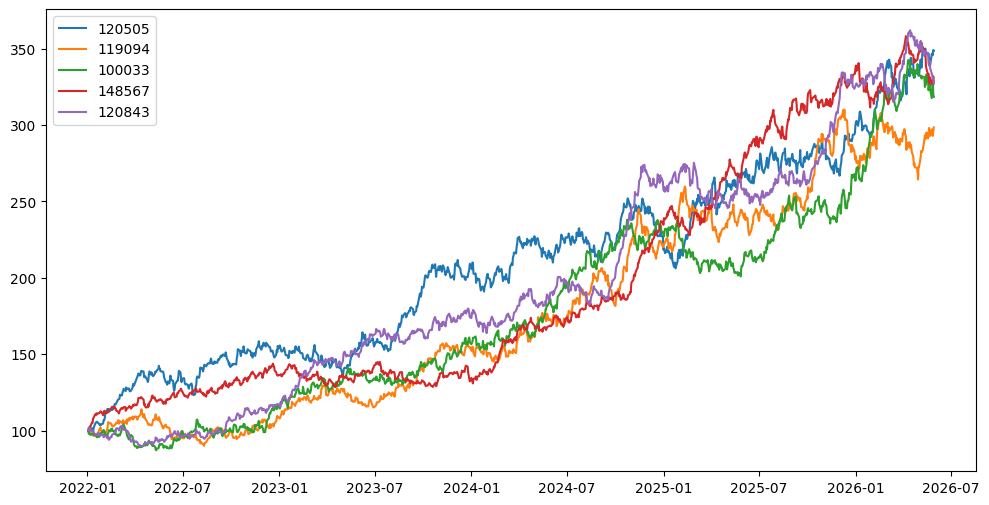

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for scheme in top5["amfi_code"]:

    temp = nav[
        nav["amfi_code"] == scheme
    ]

    print(
        scheme,
        temp.shape
    )

    plt.plot(
        temp["date"],
        temp["normalized_nav"],
        label=str(scheme)
    )

plt.legend()

plt.show()

In [55]:
benchmark["index_name"].unique()

<ArrowStringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [56]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark["date"].min(), benchmark["date"].max()

(Timestamp('2022-01-03 00:00:00'), Timestamp('2026-05-29 00:00:00'))

In [59]:
benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark["normalized_value"] = (
    benchmark.groupby("index_name")["close_value"]
    .transform(
        lambda x: x / x.iloc[0] * 100
    )
)

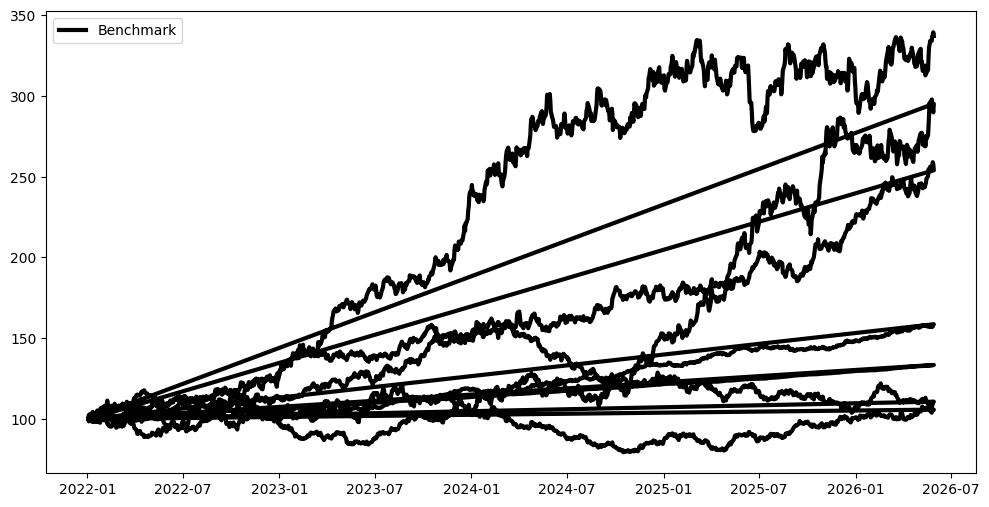

In [60]:
plt.figure(figsize=(12,6))

plt.plot(
    benchmark["date"],
    benchmark["normalized_value"],
    linewidth=3,
    color="black",
    label="Benchmark"
)

plt.legend()
plt.show()

In [61]:
benchmark.groupby("index_name")["normalized_value"].first()

index_name
BSE_SMALLCAP       100.0
CRISIL_GILT        100.0
CRISIL_LIQUID      100.0
NIFTY100           100.0
NIFTY50            100.0
NIFTY500           100.0
NIFTY_MIDCAP150    100.0
Name: normalized_value, dtype: float64

In [62]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

print(nifty50.shape)

nifty50.head()

(1150, 4)


,date,index_name,close_value,normalized_value
0,2022-01-03,NIFTY50,17492.79,100.000000
1,2022-01-04,NIFTY50,17689.64,101.125321
2,2022-01-05,NIFTY50,17835.05,101.956578
3,2022-01-06,NIFTY50,17878.51,102.205023
4,2022-01-07,NIFTY50,17759.15,101.522684


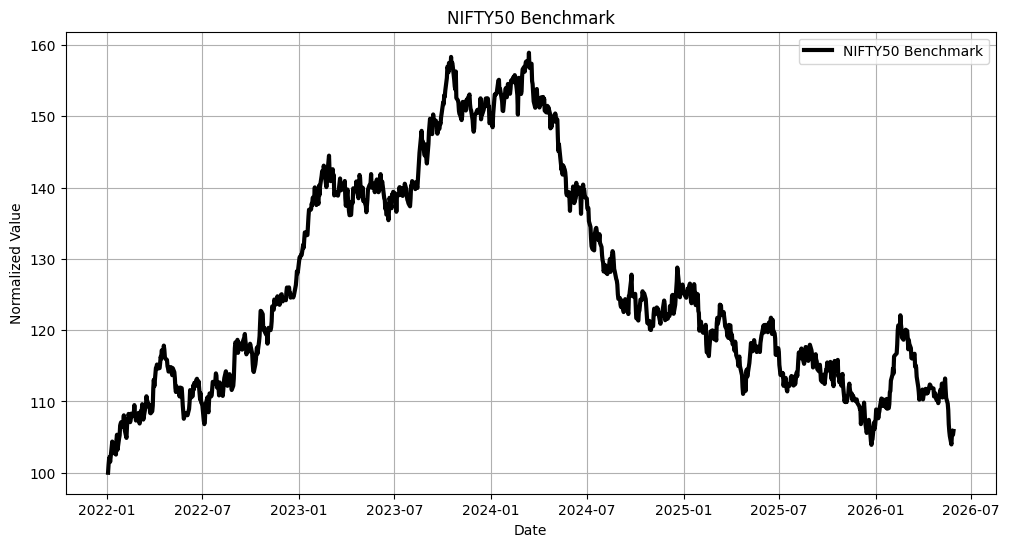

In [63]:
plt.figure(figsize=(12,6))

plt.plot(
    nifty50["date"],
    nifty50["normalized_value"],
    color="black",
    linewidth=3,
    label="NIFTY50 Benchmark"
)

plt.title("NIFTY50 Benchmark")
plt.xlabel("Date")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(True)

plt.show()

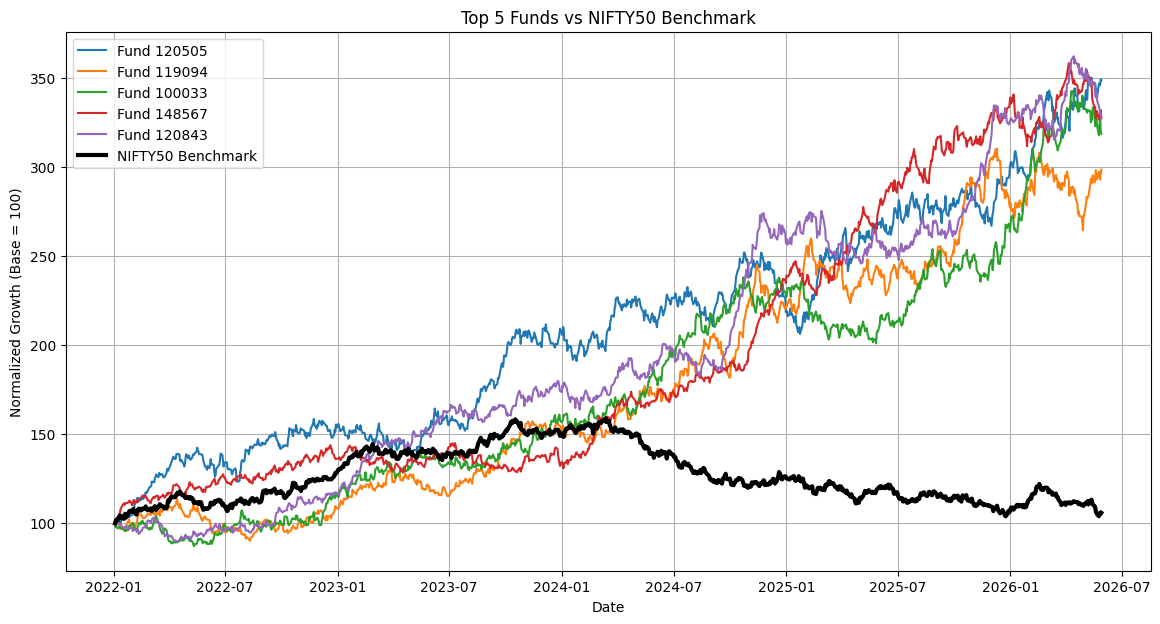

In [64]:
plt.figure(figsize=(14,7))

# Top 5 Funds
for scheme in top5["amfi_code"]:

    fund = nav[
        nav["amfi_code"] == scheme
    ]

    plt.plot(
        fund["date"],
        fund["normalized_nav"],
        label=f"Fund {scheme}"
    )

# NIFTY50 Benchmark
plt.plot(
    nifty50["date"],
    nifty50["normalized_value"],
    color="black",
    linewidth=3,
    label="NIFTY50 Benchmark"
)

plt.title("Top 5 Funds vs NIFTY50 Benchmark")
plt.xlabel("Date")
plt.ylabel("Normalized Growth (Base = 100)")
plt.legend()
plt.grid(True)

plt.savefig(
    "../reports/benchmark_comparison.png",
    bbox_inches="tight"
)

plt.show()

In [65]:
nifty50[["date", "close_value", "normalized_value"]].head()

,date,close_value,normalized_value
0,2022-01-03,17492.79,100.000000
1,2022-01-04,17689.64,101.125321
2,2022-01-05,17835.05,101.956578
3,2022-01-06,17878.51,102.205023
4,2022-01-07,17759.15,101.522684


In [66]:
nifty50[["date", "close_value", "normalized_value"]].tail()

,date,close_value,normalized_value
1145,2026-05-25,18186.57,103.966091
1146,2026-05-26,18418.36,105.291151
1147,2026-05-27,18523.57,105.892599
1148,2026-05-28,18421.08,105.306701
1149,2026-05-29,18517.65,105.858757


In [67]:
print(nifty50["close_value"].iloc[0])
print(nifty50["close_value"].iloc[-1])

17492.79
18517.65


In [68]:
final_growth = (
    nifty50["close_value"].iloc[-1]
    / nifty50["close_value"].iloc[0]
) * 100

print(final_growth)

105.8587566648888


In [71]:
cagr_results = []

for scheme in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == scheme].sort_values("date")

    start_nav = temp["nav"].iloc[0]
    end_nav = temp["nav"].iloc[-1]

    years = (
        temp["date"].max() -
        temp["date"].min()
    ).days / 365.25

    cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

    cagr_results.append([scheme, cagr])

cagr_df = pd.DataFrame(
    cagr_results,
    columns=["amfi_code", "cagr"]
)

cagr_df.head()

,amfi_code,cagr
0,100016,2.637074
1,100025,4.458210
2,100033,30.123153
3,101206,23.538361
4,101207,7.938765


In [72]:
cagr_df.to_csv("../reports/cagr_table.csv", index=False)

In [73]:
sortino

np.float64(1.619793176491409)

In [74]:
sortino_results = []

for scheme in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == scheme]

    returns = temp["daily_return"].dropna()

    downside = returns[returns < 0]

    downside_std = downside.std()

    annual_return = returns.mean() * 252

    if downside_std > 0:

        sortino = (
            (annual_return - 0.065)
            / downside_std
        ) * np.sqrt(252)

    else:
        sortino = np.nan

    sortino_results.append(
        [scheme, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-88.463960
1,100025,-237.338952
2,100033,460.941758
3,101206,453.489844
4,101207,69.714237


In [75]:
sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

In [77]:
dd_results = []

for scheme in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == scheme
    ].sort_values("date")

    running_max = temp["nav"].cummax()

    drawdown = (
        temp["nav"] / running_max
    ) - 1

    max_dd = drawdown.min()

    dd_results.append(
        [scheme, max_dd]
    )

dd_df = pd.DataFrame(
    dd_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

dd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [78]:
dd_df.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

In [80]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty50 = nifty50.sort_values("date")

nifty50["benchmark_return"] = (
    nifty50["close_value"].pct_change()
)

In [82]:
top5 = (
    scorecard
    .sort_values(
        "fund_score",
        ascending=False
    )
    .head(5)
)

top5

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score
25,120505,29.604659,31.777537,28.376762,1.180101,0.292636,0.000549,-0.181885,1.36,0.900,0.900,0.950,0.650,0.625,100.000000
16,119094,22.261065,35.111802,24.445309,0.998231,0.260767,-0.066265,-0.209609,1.38,1.000,0.750,0.800,0.600,0.700,95.562130
2,100033,53.232396,32.442459,26.074068,1.093699,0.271954,0.005104,-0.162172,1.38,0.925,0.850,0.875,0.600,0.500,95.266272
34,148567,20.360678,34.000916,26.799277,1.448291,0.269838,0.023684,-0.112657,1.46,0.975,1.000,0.850,0.450,0.200,94.674556
30,120843,26.657082,29.582770,26.742494,1.306744,0.273305,-0.022830,-0.129740,1.45,0.850,0.975,0.900,0.475,0.325,92.603550


In [83]:
top5_funds = top5["amfi_code"].tolist()

top5_funds

[120505, 119094, 100033, 148567, 120843]

In [87]:
tracking_results = []

for scheme in top5_funds:

    fund = nav[
        nav["amfi_code"] == scheme
    ][["date", "daily_return"]]

    benchmark_returns = nifty100[
        ["date", "benchmark_return"]
    ]

    merged = fund.merge(
        benchmark_returns,
        on="date"
    )

    tracking_error = (
        (
            merged["daily_return"]
            -
            merged["benchmark_return"]
        ).std()
    ) * np.sqrt(252)

    tracking_results.append(
        [scheme, tracking_error]
    )

tracking_df = pd.DataFrame(
    tracking_results,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_df

,amfi_code,tracking_error
0,120505,0.231968
1,119094,0.237652
2,100033,0.228699
3,148567,0.189664
4,120843,0.206425


In [88]:
tracking_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

In [89]:
tracking_df.sort_values(
    "tracking_error"
)

,amfi_code,tracking_error
3,148567,0.189664
4,120843,0.206425
2,100033,0.228699
0,120505,0.231968
1,119094,0.237652


In [85]:
nifty100.columns

Index(['date', 'index_name', 'close_value', 'benchmark_return'], dtype='str')

In [86]:
nav.columns

Index(['amfi_code', 'date', 'nav', 'daily_return', 'normalized_nav'], dtype='str')